### CardioRisk ML
#### Dataset Generation

In this notebook I generate a synthetic dataset that simulates clinical records of adult
patients undergoing cardiovascular screening.

My goal is to build a dataset realistic enough to demonstrate a complete data science
pipeline in a healthcare context, from raw data generation through to predictive model
explainability.

The generation process is calibrated against population distributions drawn from
reference epidemiological studies, including the **Framingham Heart Study** and **NHANES**.
Correlations between variables follow well-established clinical relationships:

- blood pressure increases with age, BMI, and smoking
- HDL rises with physical activity and is naturally higher in women
- diabetes and hypertension are derived probabilistically from lab results
- the cardiovascular risk score is inspired by the Framingham Risk Equation

The dataset produced here is used in all subsequent notebooks of the project.
All random processes are seeded for full reproducibility.

In [1]:
"""
I configure global settings for reproducibility, plotting aesthetics,
and directory structure before generating any data.
"""

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Directory layout
RAW_DIR     = Path("../data/raw")
FIGURES_DIR = Path("../data/eda_charts")

RAW_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Global constants 
RANDOM_STATE  = 42          # seed for full reproducibility
N_PATIENTS    = 10_000      # total records to generate

np.random.seed(RANDOM_STATE)

# Plot defaults 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)


def save_plot(name: str) -> None:
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


print(f"Patients to generate : {N_PATIENTS:,}  |  Random seed : {RANDOM_STATE}")

Patients to generate : 10,000  |  Random seed : 42


#### Demographic Variables

I generate age using a truncated normal distribution between 30 and 80 years,
reflecting the age range where cardiovascular risk is clinically relevant.
Sex and race follow proportions typical of mixed population studies.

In [2]:
"""
Demographic variable generation.
"""

N = N_PATIENTS

# Age clinically relevant range 30–80 years
age = np.clip(np.random.normal(54, 12, N), 30, 80).astype(int)

# Sex balanced 50/50 split
sex = np.random.choice(
    ["Male", "Female"],
    size=N,
    p=[0.50, 0.50],
)

# Race/ethnicity proportions consistent with mixed-population studies
race = np.random.choice(
    ["White", "Black", "Hispanic", "Asian", "Other"],
    size=N,
    p=[0.45, 0.20, 0.18, 0.12, 0.05],
)

is_male = sex == "Male"  # boolean mask, reused in subsequent cells

vals, counts = np.unique(sex, return_counts=True)
sex_counts   = {str(k): int(v) for k, v in zip(vals, counts)}

print(f"Age  : {age.min()}–{age.max()} years  |  mean = {age.mean():.1f}")
print(f"Sex  : {sex_counts}")

Age  : 30–80 years  |  mean = 53.5
Sex  : {'Female': 5124, 'Male': 4876}


#### Anthropometrics

I generate height and weight separately by sex, with a gradual age-related weight
increase. BMI is computed using the standard WHO formula, and waist circumference
is derived from BMI with individual noise, respecting sex-specific clinical cut-offs.

In [3]:
"""
Height as sex-stratified normal distributions and introduce
a mild age-driven weight increment to replicate the gradual weight gain
observed across adulthood in epidemiological cohorts.
"""

# Age-related weight adjustment: +0.08 kg per year above 30
age_weight_adj = (age - 30) * 0.08

height_cm = np.where(
    is_male,
    np.random.normal(175, 7, N),   # male: mean 175 cm
    np.random.normal(162, 6, N),   # female: mean 162 cm
).clip(148, 200).round(1)

weight_kg = np.where(
    is_male,
    np.random.normal(82, 15, N) + age_weight_adj * 0.5,
    np.random.normal(68, 13, N) + age_weight_adj * 0.3,
).clip(45, 160).round(1)

# BMI [kg / m²]
bmi = (weight_kg / (height_cm / 100) ** 2).round(1)

# Waist circumference derived from BMI with sex-specific baselines
waist_cm = np.where(
    is_male,
    75 + (bmi - 18.5) * 1.8 + np.random.normal(0, 5, N),
    65 + (bmi - 18.5) * 1.6 + np.random.normal(0, 5, N),
).clip(60, 145).round(1)

print(f"BMI   : {bmi.min():.1f}–{bmi.max():.1f}  |  mean = {bmi.mean():.1f} kg/m²")
print(f"Waist : mean = {waist_cm.mean():.1f} cm")

BMI   : 11.8–51.8  |  mean = 26.8 kg/m²
Waist : mean = 84.1 cm


#### Lifestyle Variables

I capture lifestyle behaviours that have a direct impact on clinical markers and
cardiovascular risk. The physical activity score is used as an adjustment variable
in subsequent calculations.

In [4]:
"""
Physical activity as an ordered numeric score (0–3) so that it
can be used directly as a continuous adjustment factor in later formulas
without requiring a separate ordinal encoder at this stage.
"""

# Smoking status (never / former / current)
smoking = np.random.choice(
    ["Never smoked", "Former smoker", "Current smoker"],
    size=N,
    p=[0.55, 0.25, 0.20],
)

# Physical activity level
physical_activity = np.random.choice(
    ["Sedentary", "Light", "Moderate", "Intense"],
    size=N,
    p=[0.35, 0.30, 0.25, 0.10],
)

# Alcohol consumption
alcohol_use = np.random.choice(
    ["Non-drinker", "Moderate", "Heavy"],
    size=N,
    p=[0.40, 0.42, 0.18],
)

# Diet quality scored 1–10 (10 = healthiest)
diet_quality = np.clip(np.random.normal(5.5, 2.0, N), 1, 10).round(0).astype(int)

# Sleep hours per night
sleep_hours = np.clip(np.random.normal(6.8, 1.2, N), 3, 10).round(1)

# Stress level scored 1–10 (10 = highest)
stress_level = np.clip(np.random.normal(5.2, 2.2, N), 1, 10).round(0).astype(int)

# Numeric physical activity score (Sedentary=0 → Intense=3)
pa_score = np.select(
    [
        physical_activity == "Sedentary",
        physical_activity == "Light",
        physical_activity == "Moderate",
        physical_activity == "Intense",
    ],
    [0, 1, 2, 3],
)

print("Lifestyle variables generated.")

Lifestyle variables generated.


#### Vital Signs

I model blood pressure as a function of a patient's baseline risk score, which
aggregates the main modifiable risk factors. Resting heart rate decreases with
higher physical activity levels.

In [5]:
"""
Baseline risk score computation and vital signs generation.
I construct a composite baseline risk score that summarises each
patient's overall cardiovascular burden. This score drives several
downstream clinical variables, capturing the known physiological
relationships between risk factors and measurable outcomes.
"""

# Baseline risk score
brs = (
    (age  - 30)   * 0.30
    + (bmi - 22)  * 0.80
    + np.where(smoking == "Current smoker", 8, 0)
    + np.where(smoking == "Former smoker",  3, 0)
    + np.where(is_male,                     4, 0)
    + (3 - pa_score)   * 2.50
    + (10 - diet_quality) * 0.50
    + stress_level     * 0.40
    + np.where(alcohol_use == "Heavy",      3, 0)
)

# Systolic blood pressure [mmHg]
sbp = (105 + brs * 0.55 + np.random.normal(0, 10, N)).clip(90,  200).round(0)

# Diastolic blood pressure [mmHg], derived from SBP with physiological noise
dbp = (sbp * 0.60 + 10  + np.random.normal(0,  6, N)).clip(55,  120).round(0)

# Resting heart rate, decreases with fitness, increases with excess weight
rhr = (
    80 - pa_score * 4
    + (bmi - 25) * 0.30
    + np.random.normal(0, 8, N)
).clip(45, 110).round(0).astype(int)

print(f"SBP : {sbp.mean():.1f} mmHg  |  "
      f"DBP : {dbp.mean():.1f} mmHg  |  "
      f"RHR : {rhr.mean():.1f} bpm")

SBP : 118.7 mmHg  |  DBP : 81.2 mmHg  |  RHR : 76.2 bpm


#### Laboratory Results

I generate the lipid panel and glycaemic markers with realistic clinical
correlations. HDL is the only marker with a protective effect, it increases
with physical activity and is naturally higher in women. LDL worsens with poor
diet and sedentary behaviour.

In [6]:
"""
Risk score to drive directional changes in each lab
value, preserving the well-documented inverse relationship between HDL
and cardiovascular risk, and the direct relationships for LDL,
triglycerides, and glucose.
HbA1c is derived from fasting glucose using the ADA conversion formula
with added individual-level noise.
"""

# HDL cholesterol [mg/dL]. Protective, rises with fitness, falls with risk
hdl = (
    60
    + pa_score     * 3.0
    + np.where(sex == "Female", 8, 0)
    + diet_quality * 0.8
    - (bmi - 22)   * 0.6
    - np.where(smoking == "Current smoker", 7, 0)
    - brs          * 0.25
    + np.random.normal(0, 10, N)
).clip(25, 100).round(1)

# LDL cholesterol [mg/dL]
ldl = (
    90
    + brs          * 0.7
    + (10 - diet_quality) * 2.0
    - pa_score     * 4.0
    + np.random.normal(0, 20, N)
).clip(40, 250).round(1)

# Triglycerides [mg/dL]. Elevated by heavy alcohol and obesity
triglycerides = (
    100
    + brs * 1.2
    + np.where(alcohol_use == "Heavy", 30, 0)
    + (bmi - 22)   * 3.0
    - pa_score     * 8.0
    + np.random.normal(0, 30, N)
).clip(40, 600).round(1)

# Total cholesterol [mg/dL]. Friedewald approximation
total_cholesterol = (ldl + hdl + triglycerides / 5).round(1)

# Fasting glucose [mg/dL]
glucose = (
    80
    + brs  * 0.6
    + (bmi - 22) * 1.5
    - pa_score   * 3.0
    + np.random.normal(0, 15, N)
).clip(65, 350).round(1)

# HbA1c [%]. ADA formula with individual biological noise
hba1c = (glucose / 28.7 + 0.5 + np.random.normal(0, 0.3, N)).clip(4.0, 14.0).round(1)

print(f"LDL     : {ldl.mean():.1f} mg/dL")
print(f"HDL     : {hdl.mean():.1f} mg/dL")
print(f"Glucose : {glucose.mean():.1f} mg/dL")

LDL     : 111.8 mg/dL
HDL     : 61.3 mg/dL
Glucose : 99.0 mg/dL


#### Medical History

I derive diabetes and hypertension probabilistically from lab results,
replicating the real diagnostic process. Cardiovascular medication
probability is higher in patients with hypertension, diabetes, or elevated LDL.

In [7]:
"""
Diagnosis probabilities as functions of measurable lab values,
mirroring clinical diagnostic criteria (ADA for diabetes, JNC/ACC-AHA
for hypertension). Medication use is then derived from these diagnoses
and from dyslipidaemia flags.
"""

# Diabetes
# Probabilistic model based on fasting glucose and HbA1c thresholds
prob_diabetes = (
    np.where(glucose >= 126, 0.85, 0)               # fasting ≥ 126 mg/dL
    + np.where((glucose >= 100) & (glucose < 126), 0.30, 0)  # pre-diabetic range
    + np.where(hba1c  >= 6.5,  0.20, 0)             # HbA1c diagnostic threshold
    + (bmi - 22).clip(0, 20) * 0.01                 # obesity contribution
).clip(0, 1)

diabetes = np.random.binomial(1, prob_diabetes).astype(bool)

# Hypertension 
# ACC/AHA 2017 thresholds. Stage 1 ≥130, Stage 2 ≥140 mmHg systolic
prob_hypertension = (
    np.where(sbp >= 140, 0.90, 0)
    + np.where((sbp >= 130) & (sbp < 140), 0.60, 0)
    + np.where((sbp >= 120) & (sbp < 130), 0.20, 0)
    + np.where(dbp >= 90,  0.40, 0)
).clip(0, 1)

hypertension = np.random.binomial(1, prob_hypertension).astype(bool)

# Family history of CVD 
family_history_cvd = np.random.choice([True, False], N, p=[0.28, 0.72])

# Cardiovascular medication use 
prob_medication = (
    np.where(hypertension, 0.65, 0.05)
    + np.where(diabetes,   0.50, 0)
    + np.where(ldl > 160,  0.40, 0)
).clip(0, 1)

cv_medication = np.random.binomial(1, prob_medication).astype(bool)

print(f"Diabetes      : {diabetes.mean() * 100:.1f}%")
print(f"Hypertension  : {hypertension.mean() * 100:.1f}%")
print(f"Family history: {family_history_cvd.mean() * 100:.1f}%")
print(f"On CV meds    : {cv_medication.mean() * 100:.1f}%")

Diabetes      : 24.2%
Hypertension  : 22.9%
Family history: 28.0%
On CV meds    : 29.9%


#### Target Variable

I calculate cardiovascular risk using a composite score inspired by the Framingham
Risk Equation, converted to a probability via sigmoid function. Random noise is
kept deliberately low (σ = 3) to represent residual biological variability without
compromising class separability.

In [8]:
"""
I compute the Framingham-inspired linear risk score, then pass it through a
logistic (sigmoid) function to obtain a smooth probability in [0, 1].
The binary target is then sampled from a Bernoulli distribution with
that probability, introducing stochasticity analogous to real-world
outcome variability.
"""

risk_score = (
    (age  - 30)       * 0.40
    + np.where(is_male, 6, 0)
    + (sbp - 110)     * 0.25
    + (ldl - 100)     * 0.12
    + (60 - hdl).clip(0, 40) * 0.18
    + (triglycerides - 150).clip(0) * 0.04
    + (bmi  - 22)     * 0.60
    + np.where(diabetes,           22, 0)
    + np.where(hypertension,       15, 0)
    + np.where(family_history_cvd, 12, 0)
    + np.where(smoking == "Current smoker", 16, 0)
    + np.where(smoking == "Former smoker",   6, 0)
    + (3 - pa_score)  * 4.00
    + (10 - diet_quality) * 0.80
    + np.where(alcohol_use == "Heavy",  6, 0)
    + stress_level    * 0.60
    + np.random.normal(0, 3, N)   # residual biological noise
)

# Sigmoid transformation, centred at 58 with scale 10
risk_probability  = 1 / (1 + np.exp(-(risk_score - 58) / 10))

# Binary target, 1 = high risk, 0 = low risk
cardiovascular_risk = np.random.binomial(1, risk_probability)

print(f"High risk  : {cardiovascular_risk.sum():,}  ({cardiovascular_risk.mean() * 100:.1f}%)")
print(f"Low risk   : {(cardiovascular_risk == 0).sum():,}  ({(cardiovascular_risk == 0).mean() * 100:.1f}%)")

High risk  : 4,026  (40.3%)
Low risk   : 5,974  (59.7%)


#### Dataset Assembly and Export

I consolidate all generated arrays into a single DataFrame, and export to CSV for use in subsequent notebooks.

In [9]:
"""
Assemble all generated arrays into a single tidy DataFrame with
descriptive column names, validate its integrity, and save it
to the raw data directory.
"""

df = pd.DataFrame({
    # Identifiers 
    "patient_id":               [f"PAT_{str(i).zfill(5)}" for i in range(1, N + 1)],

    # Demographics 
    "age":                      age,
    "sex":                      sex,
    "race":                     race,

    # Anthropometrics 
    "height_cm":                height_cm,
    "weight_kg":                weight_kg,
    "bmi":                      bmi,
    "waist_circumference_cm":   waist_cm,

    # Vital signs 
    "systolic_bp_mmhg":         sbp,
    "diastolic_bp_mmhg":        dbp,
    "resting_hr_bpm":           rhr,

    # Lipid panel
    "total_cholesterol_mg_dl":  total_cholesterol,
    "ldl_mg_dl":                ldl,
    "hdl_mg_dl":                hdl,
    "triglycerides_mg_dl":      triglycerides,

    # Glycaemic markers 
    "fasting_glucose_mg_dl":    glucose,
    "hba1c_pct":                hba1c,

    # Lifestyle 
    "smoking":                  smoking,
    "physical_activity":        physical_activity,
    "alcohol_use":              alcohol_use,
    "diet_quality":             diet_quality,
    "sleep_hours":              sleep_hours,
    "stress_level":             stress_level,

    # Medical history 
    "diabetes":                 diabetes.astype(int),
    "hypertension":             hypertension.astype(int),
    "family_history_cvd":       family_history_cvd.astype(int),
    "cv_medication":            cv_medication.astype(int),

    # Target 
    "cardiovascular_risk":      cardiovascular_risk,
})

# Integrity checks
assert df.isnull().sum().sum() == 0, "Unexpected nulls in dataset!"
assert df.duplicated().sum()   == 0, "Unexpected duplicate rows!"

# Export
output_path = RAW_DIR / "cardiovascular_patients.csv"
df.to_csv(output_path, index=False, encoding="utf-8")

print(f"Dataset saved to : {output_path}")
print(f"Shape            : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"Nulls            : {df.isnull().sum().sum()}")
print(f"Duplicates       : {df.duplicated().sum()}")

Dataset saved to : ../data/raw/cardiovascular_patients.csv
Shape            : 10,000 rows  ×  28 columns
Nulls            : 0
Duplicates       : 0


#### Dataset Overview

In [10]:
"""
Display a concise summary to verify that the generated distributions
are physiologically plausible before passing the dataset downstream.
"""

clinical_cols = [
    "age", "bmi", "systolic_bp_mmhg",
    "ldl_mg_dl", "hdl_mg_dl", "fasting_glucose_mg_dl",
]

df[clinical_cols].describe().round(2)

,age,bmi,systolic_bp_mmhg,ldl_mg_dl,hdl_mg_dl,fasting_glucose_mg_dl
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00
mean,53.53,26.8,118.71,111.79,61.31,99.03
std,11.61,5.3,10.77,21.87,13.11,18.68
min,30.00,11.8,90.00,40.00,25.00,65.00
25%,45.00,23.0,111.00,97.10,52.50,85.50
50%,53.00,26.7,119.00,111.85,61.40,99.00
75%,62.00,30.4,126.00,126.60,70.30,111.70
max,80.00,51.8,161.00,192.10,100.00,170.20


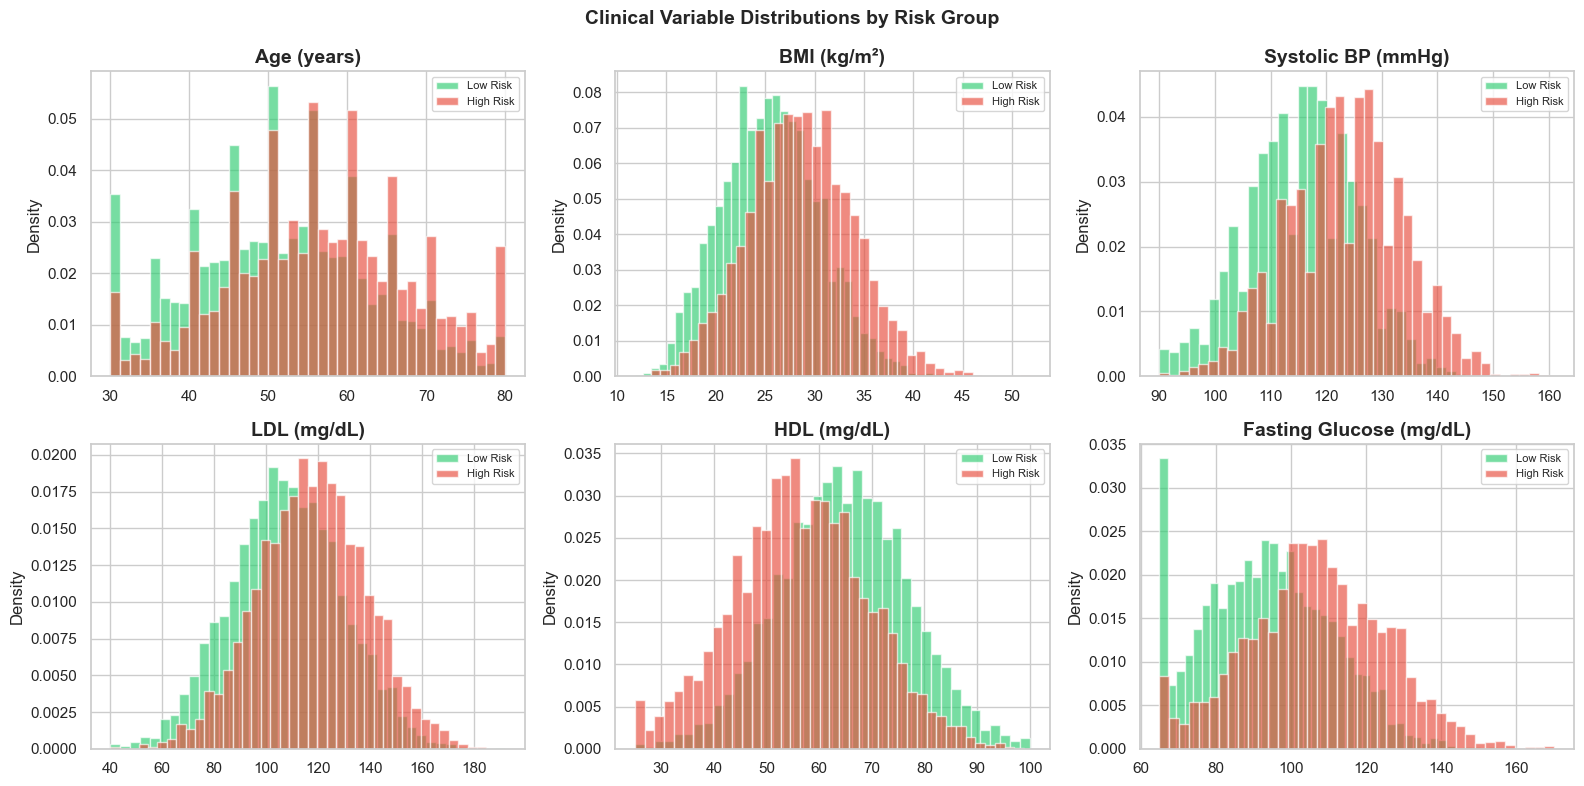

In [11]:
"""
Overlay histograms split by cardiovascular risk class so any
generation artefacts are immediately visible before moving to the EDA notebook.
"""

COLOR_LOW  = "#2ECC71"
COLOR_HIGH = "#E74C3C"

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Clinical Variable Distributions by Risk Group",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

labels_map = {
    "age":                   "Age (years)",
    "bmi":                   "BMI (kg/m²)",
    "systolic_bp_mmhg":      "Systolic BP (mmHg)",
    "ldl_mg_dl":             "LDL (mg/dL)",
    "hdl_mg_dl":             "HDL (mg/dL)",
    "fasting_glucose_mg_dl": "Fasting Glucose (mg/dL)",
}

for ax, (col, label) in zip(axes, labels_map.items()):
    for group, color, name in [
        (df[df.cardiovascular_risk == 0], COLOR_LOW,  "Low Risk"),
        (df[df.cardiovascular_risk == 1], COLOR_HIGH, "High Risk"),
    ]:
        ax.hist(group[col], bins=40, alpha=0.65, color=color,
                label=name, edgecolor="white", density=True)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
save_plot("00_generation_sanity_check")
plt.show()